# Gene expression scatter — predicted vs observed (test intervals)

## imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODALITIES = {
    "rna_seq":          "#717EC3",
    "splice_site":      "#AE8799",
    "splice_usage":     "#C95D63",
    "splice_junctions": "#EE8434",
}

PAL_SAMPLES = {
    "WT":    "#C5CBD3",
    "K700E": "#8D6A9F",
}


## paths

In [2]:
ROOT     = ".."
EVAL_DIR = os.path.join(ROOT, "results", "bsc", "evaluation", "alphagenome_pytorch", "full")

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_NAME = "randinit__newloss__annotated__frozen__multigpu_ddp"
EPOCH    = 10
SUBSET   = "test"

SAMPLE_LABELS = {
    "SRR17111303": "WT",
    "SRR17111311": "K700E",
}


## data

In [3]:
pred_dir = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), SUBSET, "predictions")
rna_df   = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene.parquet"))

rna_df["sample"] = rna_df["track_name"].map(SAMPLE_LABELS)

rna_df.to_parquet(
    os.path.join(OUTPUT_DIR, "kundaje_rna_seq_per_gene_epoch{}.parquet".format(EPOCH)),
    index=False, compression="zstd",
)

print(rna_df.shape)
print(rna_df["sample"].value_counts())
rna_df.head()

(13262, 10)
sample
WT       6631
K700E    6631
Name: count, dtype: int64


,gene_id,gene_name,chrom,strand,interval_idx,track_idx,track_name,pred_log_mean,obs_log_mean,sample
0,ENSG00000101323.5,HAO1,chr20,-,0,1,SRR17111303,0.008854,0.000000,WT
1,ENSG00000101323.5,HAO1,chr20,-,0,3,SRR17111311,0.020861,0.000000,K700E
2,ENSG00000125827.9,TMX4,chr20,-,0,1,SRR17111303,3.118415,4.135792,WT
3,ENSG00000125827.9,TMX4,chr20,-,0,3,SRR17111311,3.225172,5.146677,K700E
4,ENSG00000215586.2,ENSG00000215586,chr20,-,0,1,SRR17111303,0.017919,0.000000,WT


In [4]:
corr_rows = []
for sample, sub in rna_df.groupby("sample"):
    sub = sub.dropna(subset=["pred_log_mean", "obs_log_mean"])
    r, _   = stats.pearsonr(sub["obs_log_mean"], sub["pred_log_mean"])
    rho, _ = stats.spearmanr(sub["obs_log_mean"], sub["pred_log_mean"])
    corr_rows.append({"sample": sample, "pearson_r": r, "spearman_rho": rho, "n": len(sub)})

corr_df = pd.DataFrame(corr_rows).set_index("sample").loc[list(SAMPLE_LABELS.values())]
print(corr_df)


        pearson_r  spearman_rho     n
sample                               
WT       0.901071      0.776657  6631
K700E    0.897334      0.776178  6631


## figures

### predicted vs observed mean gene expression (log mean exon coverage), faceted by sample

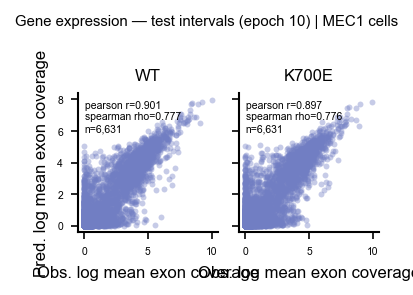

saved: pdfs/kundaje_gene_expr_scatter_epoch10.pdf


In [5]:
SAMPLE_ORDER = list(SAMPLE_LABELS.values())

g = sns.relplot(
    data=rna_df,
    kind="scatter",
    x="obs_log_mean", y="pred_log_mean",
    col="sample",
    col_order=SAMPLE_ORDER,
    color=PAL_MODALITIES["rna_seq"],
    s=8, alpha=0.4, linewidth=0,
    rasterized=True,
    height=4.5 * cm, aspect=0.7,
    facet_kws={"sharex": True, "sharey": True},
)

g.set_axis_labels("Obs. log mean exon coverage", "Pred. log mean exon coverage")
g.set_titles("{col_name}")

for ax, sample in zip(g.axes.flat, SAMPLE_ORDER):
    r   = corr_df.loc[sample, "pearson_r"]
    rho = corr_df.loc[sample, "spearman_rho"]
    n   = int(corr_df.loc[sample, "n"])
    ax.text(
        0.05, 0.95,
        "pearson r={:.3f}\nspearman rho={:.3f}\nn={:,}".format(r, rho, n),
        transform=ax.transAxes, fontsize=5, va="top",
    )
    ax.tick_params(labelsize=5)
    sns.despine(ax=ax)

g.figure.suptitle("Gene expression — {} intervals (epoch {}) | MEC1 cells".format(SUBSET, EPOCH), y=1.05)
plt.tight_layout()

outfile = os.path.join(OUTPUT_DIR, "kundaje_gene_expr_scatter_epoch{}.pdf".format(EPOCH))
g.figure.savefig(outfile, bbox_inches="tight")
plt.show()
print("saved:", outfile)
